# Notebook 2 — Intermediate and Expert Outlier Detection

## Project Continuation

In the previous notebook, we completed the Beginner section using the Z-Score method.

We detected statistical outliers using:

`absolute Z-Score > 3`

Now we move to the Intermediate section.

In this notebook, we will use model-based outlier detection methods:

1. **Isolation Forest**
2. **Local Outlier Factor**
3. **PCA 2D visualization**
4. **Jaccard coefficient comparison**

We will first work with the Industrial Equipment Monitoring dataset using the sensor columns:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

Each row is one machine observation, also called one data point.

Later, for the Expert section, we will use the KDD Cup 1999 dataset and build an Autoencoder for anomaly detection.

In [1]:
# ============================================================
# Notebook 2: Intermediate and Expert Outlier Detection
# Cell 1: Load dataset and prepare sensor columns
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Project settings
# ------------------------------------------------------------

RANDOM_STATE = 42
CONTAMINATION = 0.05

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

# The CSV should be in the same folder as this notebook.
DATA_PATH = Path.cwd() / "equipment_anomaly_data.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"CSV file not found: {DATA_PATH}\n"
        "Please place equipment_anomaly_data.csv in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

# ------------------------------------------------------------
# Select sensor columns
# ------------------------------------------------------------

sensor_columns = ["temperature", "pressure", "vibration", "humidity"]

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Sensor columns selected: {sensor_columns}")

display(df.head())
display(df[sensor_columns].describe().T)

Dataset loaded successfully.
Shape: 7672 rows and 7 columns
Sensor columns selected: ['temperature', 'pressure', 'vibration', 'humidity']


,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


,count,mean,std,min,25%,50%,75%,max
temperature,7672.0,70.922478,16.200059,10.269385,62.777057,70.156900,77.568387,149.690420
pressure,7672.0,35.738048,10.381593,3.620798,29.485682,35.227544,41.159913,79.887734
vibration,7672.0,1.611809,0.728560,-0.428188,1.170906,1.533113,1.924700,4.990537
humidity,7672.0,50.016574,11.841479,10.215077,42.612817,50.024744,57.340513,89.984718


In [2]:
# ============================================================
# Cell 2: Prepare and scale sensor features
# ============================================================

from sklearn.preprocessing import StandardScaler

# Use only the sensor columns as model input.
X = df[sensor_columns].copy()

# StandardScaler puts all sensor columns on a comparable scale.
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

# Convert the scaled array back into a dataframe for readability.
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=sensor_columns,
    index=df.index
)

print("Feature preparation completed.")
print(f"Original feature shape: {X.shape}")
print(f"Scaled feature shape: {X_scaled.shape}")

display(X.head())
display(X_scaled.head())

Feature preparation completed.
Original feature shape: (7672, 4)
Scaled feature shape: (7672, 4)


,temperature,pressure,vibration,humidity
0,58.180180,25.029278,0.606516,45.694907
1,75.740712,22.954018,2.338095,41.867407
2,71.358594,27.276830,1.389198,58.954409
3,71.616985,32.242921,1.770690,40.565138
4,66.506832,45.197471,0.345398,43.253795


,temperature,pressure,vibration,humidity
0,-0.786610,-1.031582,-1.379925,-0.364984
1,0.297440,-1.231493,0.996943,-0.688233
2,0.026922,-0.815074,-0.305569,0.754840
3,0.042873,-0.336688,0.218089,-0.798215
4,-0.272588,0.911232,-1.738352,-0.571147


### Cell 2 Conclusion — Sensor Features Prepared and Scaled

The sensor feature preparation step was completed successfully.

We created two feature datasets:

- `X`: original sensor values
- `X_scaled`: standardized sensor values

Both datasets contain:

- **7,672 rows**
- **4 sensor columns**

The selected sensor columns are:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

The first table shows the original sensor values in their real measurement scale.  
The second table shows the same values after standard scaling.

After scaling, each sensor column is transformed so that it has approximately:

- mean = `0`
- standard deviation = `1`

This is important because model-based methods such as **Local Outlier Factor** compare distances between rows.  
Without scaling, a sensor with larger numeric values could dominate the distance calculation.

The scaled values are similar in interpretation to Z-Scores: they show how far each reading is from the average of its own sensor column.

Now the feature data is ready for the Intermediate models:

- Isolation Forest
- Local Outlier Factor
- PCA visualization
- Jaccard comparison

## Step 3 — Train Isolation Forest

Isolation Forest is an unsupervised outlier detection algorithm.

It works by randomly splitting the data and checking how quickly each row can be isolated.

The idea is simple:

- normal rows usually need more splits to separate
- unusual rows are easier to isolate
- rows that are isolated quickly are treated as possible outliers

We use:

`contamination = 0.05`

This means we tell the model to expect approximately **5%** of the rows to be outliers.

In [3]:
# ============================================================
# Cell 3: Train Isolation Forest
# ============================================================

from sklearn.ensemble import IsolationForest

# Create the Isolation Forest model.
# contamination=0.05 means the model will flag around 5% of rows as outliers.
iso_forest = IsolationForest(
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE
)

# Fit the model and predict outlier labels.
# Output labels:
#  1  = normal row
# -1  = outlier row
iso_labels = iso_forest.fit_predict(X_scaled)

# Add results to dataframe
df_intermediate = df.copy()

df_intermediate["isolation_forest_label"] = iso_labels

# Convert labels into a clearer boolean flag.
# True  = outlier
# False = normal
df_intermediate["isolation_forest_outlier"] = (
    df_intermediate["isolation_forest_label"] == -1
)

# Count outliers
iso_outlier_count = df_intermediate["isolation_forest_outlier"].sum()
iso_outlier_percentage = iso_outlier_count / len(df_intermediate) * 100

print("Isolation Forest training completed.")
print(f"Contamination setting: {CONTAMINATION}")
print(f"Isolation Forest outliers detected: {iso_outlier_count}")
print(f"Outlier percentage: {iso_outlier_percentage:.2f}%")

display(
    df_intermediate[
        sensor_columns + ["equipment", "location", "faulty", "isolation_forest_outlier"]
    ].head()
)

Isolation Forest training completed.
Contamination setting: 0.05
Isolation Forest outliers detected: 384
Outlier percentage: 5.01%


,temperature,pressure,vibration,humidity,equipment,location,faulty,isolation_forest_outlier
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0,False
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0,False
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0,False
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0,False
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0,False


### Cell 3 Conclusion — Isolation Forest Outliers Detected

The Isolation Forest model was trained successfully on the scaled sensor features.

We used the setting:

`contamination = 0.05`

This tells the model to expect approximately **5%** of the dataset to be outliers.

The model detected:

- **384 Isolation Forest outlier rows**
- **5.01%** of the dataset

This result is consistent with the contamination setting.

The first five preview rows were not marked as Isolation Forest outliers.

Unlike the Z-Score method, Isolation Forest looks at all selected sensor columns together:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

This means a row can be detected as unusual because of its overall sensor pattern, 

not only because one individual sensor value is extremely high or low.

In the next step, we will train the Local Outlier Factor model 
and compare its detected outliers with Isolation Forest.

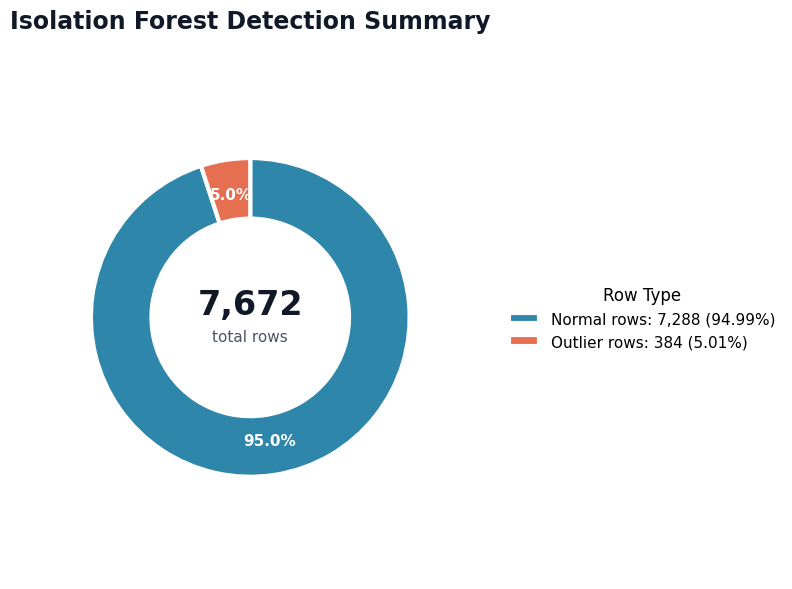

,row_type,row_count,percentage
0,Normal rows,7288,94.99
1,Isolation Forest outlier rows,384,5.01


In [4]:
# ============================================================
# Cell 3B: Professional donut chart - Isolation Forest results
# ============================================================

# Count normal and outlier rows from Isolation Forest
iso_normal_count = (~df_intermediate["isolation_forest_outlier"]).sum()
iso_outlier_count = df_intermediate["isolation_forest_outlier"].sum()
iso_total_count = len(df_intermediate)

iso_normal_pct = iso_normal_count / iso_total_count * 100
iso_outlier_pct = iso_outlier_count / iso_total_count * 100

# Data for plotting
labels = ["Normal rows", "Isolation Forest outlier rows"]
counts = [iso_normal_count, iso_outlier_count]
percentages = [iso_normal_pct, iso_outlier_pct]

# ------------------------------------------------------------
# Create professional donut chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

colors = ["#2E86AB", "#E76F51"]

wedges, texts, autotexts = ax.pie(
    counts,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%",
    startangle=90,
    counterclock=False,
    colors=colors,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.38,
        "edgecolor": "white",
        "linewidth": 3
    },
    textprops={
        "fontsize": 11,
        "fontweight": "bold",
        "color": "white"
    }
)

# Center text
ax.text(
    0,
    0.08,
    f"{iso_total_count:,}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color="#111827"
)

ax.text(
    0,
    -0.12,
    "total rows",
    ha="center",
    va="center",
    fontsize=11,
    color="#4B5563"
)

# Title
ax.set_title(
    "Isolation Forest Detection Summary",
    fontsize=17,
    fontweight="bold",
    pad=20,
    color="#111827"
)

# Legend
legend_labels = [
    f"Normal rows: {iso_normal_count:,} ({iso_normal_pct:.2f}%)",
    f"Outlier rows: {iso_outlier_count:,} ({iso_outlier_pct:.2f}%)"
]

ax.legend(
    wedges,
    legend_labels,
    title="Row Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

ax.axis("equal")

plt.tight_layout()
plt.show()

# Display summary table
iso_summary = pd.DataFrame({
    "row_type": labels,
    "row_count": counts,
    "percentage": [round(p, 2) for p in percentages]
})

display(iso_summary)

## Step 4 — Train Local Outlier Factor

Local Outlier Factor is another unsupervised outlier detection method.

LOF compares each row with its nearby rows.

The idea is simple:

- normal rows have similar nearby neighbors
- outlier rows are less dense or more isolated compared to their neighbors

In simple words:

**LOF asks whether a row is lonely compared to nearby rows.**

We again use:

`contamination = 0.05`

This means LOF will also flag around **5%** of rows as outliers.

This makes it easier to compare LOF with Isolation Forest.

In [5]:
# ============================================================
# Cell 4: Train Local Outlier Factor
# ============================================================

from sklearn.neighbors import LocalOutlierFactor

# Create the LOF model.
# contamination=0.05 means LOF will flag around 5% of rows as outliers.
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=CONTAMINATION
)

# Fit the model and predict outlier labels.
# Output labels:
#  1  = normal row
# -1  = outlier row
lof_labels = lof_model.fit_predict(X_scaled)

# Add LOF results to the intermediate dataframe.
df_intermediate["lof_label"] = lof_labels

# Convert labels into a clearer boolean flag.
# True  = outlier
# False = normal
df_intermediate["lof_outlier"] = (
    df_intermediate["lof_label"] == -1
)

# Count LOF outliers
lof_outlier_count = df_intermediate["lof_outlier"].sum()
lof_outlier_percentage = lof_outlier_count / len(df_intermediate) * 100

print("Local Outlier Factor training completed.")
print(f"Contamination setting: {CONTAMINATION}")
print(f"LOF outliers detected: {lof_outlier_count}")
print(f"Outlier percentage: {lof_outlier_percentage:.2f}%")

display(
    df_intermediate[
        sensor_columns + ["equipment", "location", "faulty", "lof_outlier"]
    ].head()
)

Local Outlier Factor training completed.
Contamination setting: 0.05
LOF outliers detected: 384
Outlier percentage: 5.01%


,temperature,pressure,vibration,humidity,equipment,location,faulty,lof_outlier
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0,False
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0,False
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0,False
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0,False
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0,False


### Cell 4 Conclusion — Local Outlier Factor Outliers Detected

The Local Outlier Factor model was trained successfully on the scaled sensor features.

We used:

`contamination = 0.05`

The model detected:

- **384 LOF outlier rows**
- **5.01%** of the dataset

This matches the expected contamination level.

LOF and Isolation Forest detected the same number of outlier rows, but this does not mean they detected the exact same rows.

The two methods use different logic:

- **Isolation Forest** detects rows that are easy to isolate through random splits.
- **LOF** detects rows that are locally unusual compared to their nearby neighbors.

In the next step, we will compare the two methods to see how many outlier rows they actually agree on.

## Step 5 — Compare Isolation Forest and LOF Outlier Counts

Both Isolation Forest and Local Outlier Factor were trained with:

`contamination = 0.05`

This means both models were expected to flag around 5% of rows as outliers.

In this step, we compare how many outliers each method detected.

Important:

Even if both methods detect the same number of outliers, they may not detect the exact same rows.

We will check row-level agreement later using the Jaccard coefficient.

Outlier count comparison:


,method,outlier_count,outlier_percentage
0,Isolation Forest,384,5.01
1,Local Outlier Factor,384,5.01


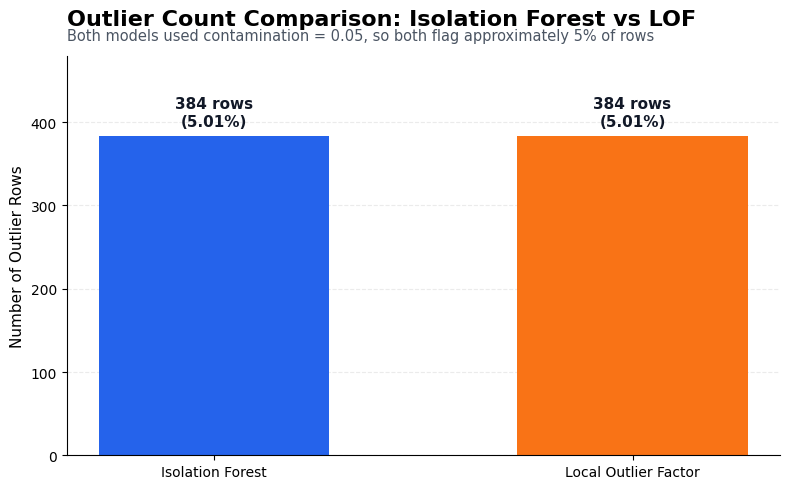

In [6]:
# ============================================================
# Cell 5: Compare Isolation Forest and LOF outlier counts
# ============================================================

# Create comparison table
method_comparison = pd.DataFrame({
    "method": ["Isolation Forest", "Local Outlier Factor"],
    "outlier_count": [
        df_intermediate["isolation_forest_outlier"].sum(),
        df_intermediate["lof_outlier"].sum()
    ]
})

method_comparison["outlier_percentage"] = (
    method_comparison["outlier_count"] / len(df_intermediate) * 100
).round(2)

print("Outlier count comparison:")
display(method_comparison)

# ------------------------------------------------------------
# Create professional comparison chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    method_comparison["method"],
    method_comparison["outlier_count"],
    color=["#2563EB", "#F97316"],
    width=0.55
)

# Add value labels
for bar, count, pct in zip(
    bars,
    method_comparison["outlier_count"],
    method_comparison["outlier_percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 8,
        f"{int(count)} rows\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#111827"
    )

# Title and subtitle
ax.set_title(
    "Outlier Count Comparison: Isolation Forest vs LOF",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=22
)

ax.text(
    0,
    1.04,
    "Both models used contamination = 0.05, so both flag approximately 5% of rows",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#4B5563"
)

# Axis labels
ax.set_ylabel("Number of Outlier Rows", fontsize=11)
ax.set_xlabel("")

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.set_ylim(0, method_comparison["outlier_count"].max() * 1.25)

plt.tight_layout()
plt.show()

### Cell 5 Conclusion — Isolation Forest vs LOF Outlier Counts

Both model-based outlier detection methods detected the same number of outlier rows.

The results are:

| Method | Outlier Rows | Outlier Percentage |
|---|---:|---:|
| Isolation Forest | 384 | 5.01% |
| Local Outlier Factor | 384 | 5.01% |

This is expected because both models were trained with:

`contamination = 0.05`

This setting asks each model to flag approximately 5% of the dataset as outliers.

However, detecting the same number of outliers does **not** mean both models detected the exact same rows.

The two methods use different logic:

- **Isolation Forest** finds rows that are easier to isolate using random splits.
- **LOF** finds rows that are locally unusual compared to nearby rows.

Therefore, the next important question is:

**How much do the two methods actually agree at the row level?**

We will answer this using the Jaccard coefficient.

## Step 6 — Calculate Jaccard Coefficient

Isolation Forest and LOF both detected **384 outlier rows**.

However, they may not have detected the exact same rows.

To measure row-level agreement, we use the **Jaccard coefficient**.

Jaccard compares two sets:

- Set A = outliers detected by Isolation Forest
- Set B = outliers detected by LOF

Formula:

`Jaccard = size of intersection / size of union`

Interpretation:

- `0` = no agreement
- `1` = perfect agreement
- values between 0 and 1 = partial agreement

In [7]:
# ============================================================
# Cell 6: Calculate Jaccard coefficient between IF and LOF
# ============================================================

# Create sets containing the row indexes detected as outliers by each method.
isolation_forest_outlier_set = set(
    df_intermediate.index[df_intermediate["isolation_forest_outlier"]]
)

lof_outlier_set = set(
    df_intermediate.index[df_intermediate["lof_outlier"]]
)

# Calculate intersection and union.
# Intersection = rows detected as outliers by both methods.
# Union = rows detected as outliers by at least one method.
outlier_intersection = isolation_forest_outlier_set.intersection(lof_outlier_set)
outlier_union = isolation_forest_outlier_set.union(lof_outlier_set)

# Calculate Jaccard coefficient.
jaccard_score = len(outlier_intersection) / len(outlier_union)

print("Jaccard coefficient calculated successfully.")
print(f"Isolation Forest outliers: {len(isolation_forest_outlier_set)}")
print(f"LOF outliers: {len(lof_outlier_set)}")
print(f"Shared outliers: {len(outlier_intersection)}")
print(f"Total unique outliers across both methods: {len(outlier_union)}")
print(f"Jaccard coefficient: {jaccard_score:.4f}")

Jaccard coefficient calculated successfully.
Isolation Forest outliers: 384
LOF outliers: 384
Shared outliers: 32
Total unique outliers across both methods: 736
Jaccard coefficient: 0.0435


### Cell 6 Conclusion — Jaccard Agreement Between Isolation Forest and LOF

The Jaccard coefficient was calculated to measure how much Isolation Forest and Local Outlier Factor agree at the row level.

The results were:

| Metric | Value |
|---|---:|
| Isolation Forest outliers | 384 |
| LOF outliers | 384 |
| Shared outliers | 32 |
| Total unique outliers across both methods | 736 |
| Jaccard coefficient | 0.0435 |

Although both methods detected the same number of outliers, they agreed on only **32 rows**.

This means the overlap between the two outlier sets is very small.

The Jaccard coefficient of **0.0435** indicates **very low agreement** between Isolation Forest and LOF.

This happens because the two methods use different logic:

- **Isolation Forest** detects rows that are easy to isolate using random splits.
- **LOF** detects rows that are locally unusual compared to nearby rows.

Therefore, the two models are identifying different types of unusual sensor behavior.

This is an important business insight because it shows that outlier detection depends heavily on the method used.

In the next step, we will visualize the agreement and disagreement between the two methods.

## Step 7 — Visualize Agreement Between Isolation Forest and LOF

The Jaccard score showed very low agreement between the two methods.

Now we create clear agreement categories:

- `Normal by both` — neither method marked the row as an outlier
- `Isolation Forest only` — only Isolation Forest marked the row as an outlier
- `LOF only` — only LOF marked the row as an outlier
- `Both methods` — both methods marked the row as an outlier

This helps us understand where the two models agree and where they disagree.

Agreement category counts:


,category,row_count,percentage
0,Normal by both,6936,90.41
1,Isolation Forest only,352,4.59
2,LOF only,352,4.59
3,Both methods,32,0.42


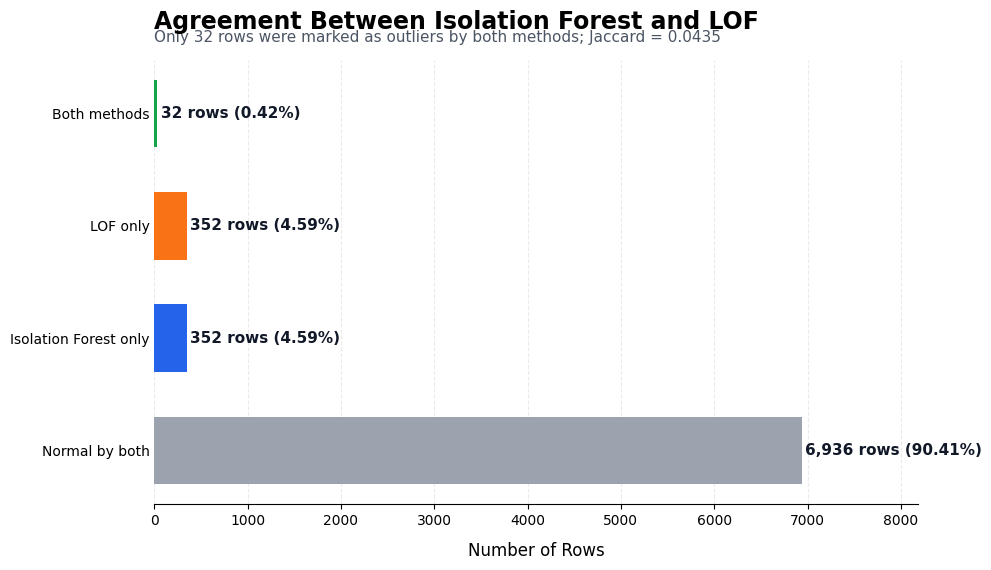

In [8]:
# ============================================================
# Cell 7: Visualize agreement between Isolation Forest and LOF
# ============================================================

# Create agreement category for each row
def assign_agreement_category(row):
    if row["isolation_forest_outlier"] and row["lof_outlier"]:
        return "Both methods"
    elif row["isolation_forest_outlier"] and not row["lof_outlier"]:
        return "Isolation Forest only"
    elif not row["isolation_forest_outlier"] and row["lof_outlier"]:
        return "LOF only"
    else:
        return "Normal by both"

df_intermediate["method_agreement"] = df_intermediate.apply(
    assign_agreement_category,
    axis=1
)

# Count rows in each category
agreement_counts = (
    df_intermediate["method_agreement"]
    .value_counts()
    .reindex(
        [
            "Normal by both",
            "Isolation Forest only",
            "LOF only",
            "Both methods"
        ]
    )
    .reset_index()
)

agreement_counts.columns = ["category", "row_count"]

agreement_counts["percentage"] = (
    agreement_counts["row_count"] / len(df_intermediate) * 100
).round(2)

print("Agreement category counts:")
display(agreement_counts)

# ------------------------------------------------------------
# Create professional horizontal bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.8))

colors = {
    "Normal by both": "#9CA3AF",
    "Isolation Forest only": "#2563EB",
    "LOF only": "#F97316",
    "Both methods": "#16A34A"
}

bars = ax.barh(
    agreement_counts["category"],
    agreement_counts["row_count"],
    color=[colors[cat] for cat in agreement_counts["category"]],
    height=0.6
)

# Add labels
for bar, count, pct in zip(
    bars,
    agreement_counts["row_count"],
    agreement_counts["percentage"]
):
    ax.text(
        bar.get_width() + 35,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count):,} rows ({pct:.2f}%)",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#111827"
    )

# Title and subtitle
ax.set_title(
    "Agreement Between Isolation Forest and LOF",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=22
)

ax.text(
    0,
    1.04,
    f"Only {len(outlier_intersection)} rows were marked as outliers by both methods; Jaccard = {jaccard_score:.4f}",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel("Number of Rows", fontsize=12, labelpad=10)
ax.set_ylabel("")

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.tick_params(axis="y", length=0)
ax.set_axisbelow(True)

# Add space for labels
ax.set_xlim(0, agreement_counts["row_count"].max() * 1.18)

plt.tight_layout()
plt.show()

### Cell 7 Conclusion — Agreement Between Isolation Forest and LOF

The agreement chart shows how Isolation Forest and Local Outlier Factor classified the rows.

The results were:

| Category | Rows | Percentage |
|---|---:|---:|
| Normal by both | 6,936 | 90.41% |
| Isolation Forest only | 352 | 4.59% |
| LOF only | 352 | 4.59% |
| Both methods | 32 | 0.42% |

Most rows were considered normal by both methods.

However, the overlap between the two outlier sets was very small.  
Only **32 rows** were detected as outliers by both Isolation Forest and LOF.

This confirms the earlier Jaccard result:

`Jaccard = 0.0435`

The low agreement means the two algorithms are identifying different types of unusual behavior.

This makes sense because:

- Isolation Forest finds rows that are easy to isolate using random splits.
- LOF finds rows that are locally unusual compared to nearby rows.

From a machine monitoring perspective, the **32 rows detected by both methods** may deserve higher priority for inspection because two different algorithms agreed that they are unusual.

In the next step, we will use PCA to visualize these model results in two dimensions.

## Step 8 — PCA 2D Visualization

The sensor dataset has four numerical features:

- `temperature`
- `pressure`
- `vibration`
- `humidity`

Because humans cannot easily visualize four dimensions at once, we use PCA to reduce the scaled sensor data into two components:

- `PC1`
- `PC2`

This allows us to create a 2D scatter plot.

In this step, we will create PCA components and add them to the dataframe so we can visualize:

- Isolation Forest outliers
- LOF outliers
- agreement and disagreement between the two methods

In [9]:
# ============================================================
# Cell 8: Create PCA components for 2D visualization
# ============================================================

from sklearn.decomposition import PCA

# Create PCA model with 2 components for 2D visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)

# Fit PCA on scaled sensor features and transform the data
pca_components = pca.fit_transform(X_scaled)

# Add PCA components to dataframe
df_intermediate["PC1"] = pca_components[:, 0]
df_intermediate["PC2"] = pca_components[:, 1]

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
total_explained_variance = explained_variance.sum()

print("PCA transformation completed.")
print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance by PC1 and PC2: {total_explained_variance:.2%}")

display(df_intermediate[["PC1", "PC2", "method_agreement"]].head())

PCA transformation completed.
PC1 explained variance: 28.20%
PC2 explained variance: 25.22%
Total explained variance by PC1 and PC2: 53.41%


,PC1,PC2,method_agreement
0,-1.888144,-0.302738,Normal by both
1,0.030940,-0.178681,Normal by both
2,-0.599878,0.864146,Normal by both
3,-0.081190,-0.636466,Normal by both
4,-0.736002,-1.073292,Normal by both


### Cell 8 Conclusion — PCA Components Created

PCA was applied successfully to the scaled sensor features.

The four original sensor columns were compressed into two new components:

- `PC1`
- `PC2`

The explained variance was:

| Component | Explained Variance |
|---|---:|
| PC1 | 28.20% |
| PC2 | 25.22% |
| PC1 + PC2 | 53.41% |

Together, the first two PCA components explain **53.41%** of the variation in the sensor data.

This means the 2D PCA plot will capture around half of the overall sensor structure.

The PCA plot is useful for visual interpretation, but it does not show 100% of the information from the original four sensor columns.

In the next step, we will create a PCA scatter plot to visualize where Isolation Forest and LOF agree or disagree on outliers.

## Step 9 — PCA Scatter Plot: Isolation Forest vs LOF Agreement

Now we visualize the model results in 2D using PCA.

Each point represents one machine observation.

The color shows how Isolation Forest and LOF classified the row:

- `Normal by both`
- `Isolation Forest only`
- `LOF only`
- `Both methods`

This chart helps us answer:

**Where do the two methods agree and disagree in the sensor feature space?**

Rows detected by both methods may be especially important because two different algorithms agreed that they are unusual.

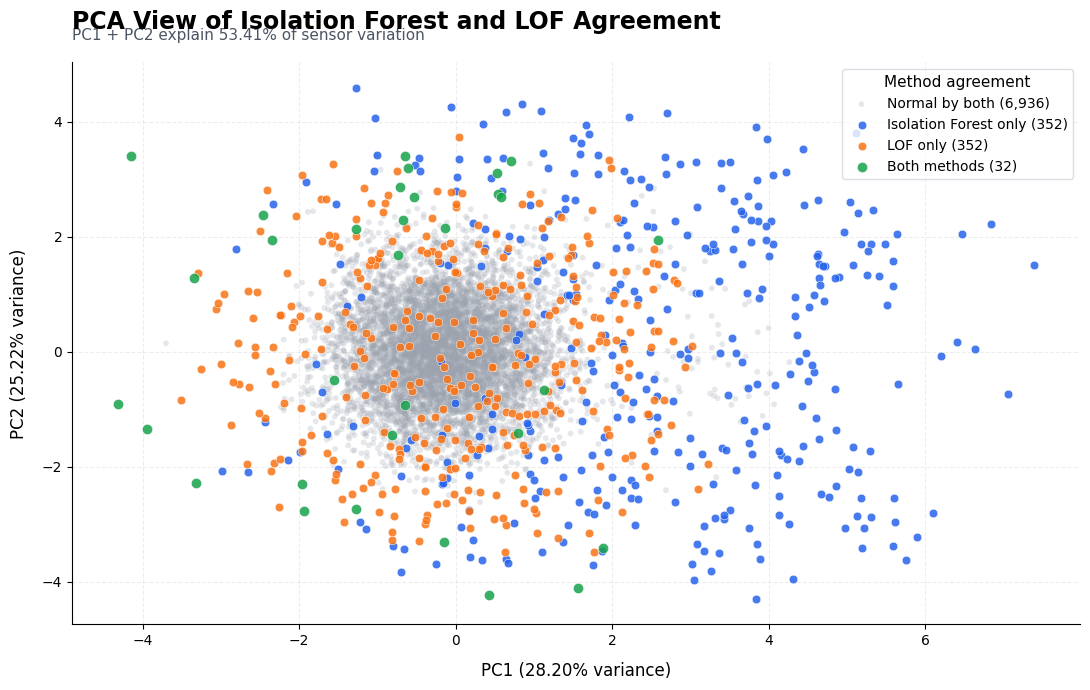

In [10]:
# ============================================================
# Cell 9: Professional PCA scatter plot - method agreement
# ============================================================

# Define plotting order so normal rows appear first and outliers appear on top
plot_order = [
    "Normal by both",
    "Isolation Forest only",
    "LOF only",
    "Both methods"
]

# Define colors for each agreement category
agreement_colors = {
    "Normal by both": "#9CA3AF",
    "Isolation Forest only": "#2563EB",
    "LOF only": "#F97316",
    "Both methods": "#16A34A"
}

# Define point sizes
agreement_sizes = {
    "Normal by both": 18,
    "Isolation Forest only": 38,
    "LOF only": 38,
    "Both methods": 55
}

# ------------------------------------------------------------
# Create PCA scatter plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

for category in plot_order:
    subset = df_intermediate[df_intermediate["method_agreement"] == category]
    
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=agreement_sizes[category],
        alpha=0.25 if category == "Normal by both" else 0.85,
        color=agreement_colors[category],
        label=f"{category} ({len(subset):,})",
        edgecolor="white" if category != "Normal by both" else "none",
        linewidth=0.4
    )

# Title and subtitle
ax.set_title(
    "PCA View of Isolation Forest and LOF Agreement",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=24
)

ax.text(
    0,
    1.04,
    f"PC1 + PC2 explain {total_explained_variance:.2%} of sensor variation",
    transform=ax.transAxes,
    fontsize=11,
    color="#4B5563"
)

# Axis labels
ax.set_xlabel(f"PC1 ({explained_variance[0]:.2%} variance)", fontsize=12, labelpad=10)
ax.set_ylabel(f"PC2 ({explained_variance[1]:.2%} variance)", fontsize=12, labelpad=10)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="both", linestyle="--", alpha=0.22)
ax.set_axisbelow(True)

# Legend
ax.legend(
    title="Method agreement",
    frameon=True,
    facecolor="white",
    edgecolor="#D1D5DB",
    fontsize=10,
    title_fontsize=11,
    loc="best"
)

plt.tight_layout()
plt.show()

### Cell 9 Conclusion — PCA Visualization of Isolation Forest and LOF Agreement

The PCA scatter plot visualizes the Isolation Forest and LOF results in two dimensions.

The first two PCA components explain:

- `PC1`: **28.20%** of sensor variation
- `PC2`: **25.22%** of sensor variation
- total: **53.41%** of sensor variation

This means the plot captures about half of the structure in the original four sensor columns.

The chart shows four groups:

- grey points: rows marked normal by both methods
- blue points: rows marked outlier only by Isolation Forest
- orange points: rows marked outlier only by LOF
- green points: rows marked outlier by both methods

The plot confirms that Isolation Forest and LOF detect different types of outliers.

Isolation Forest outliers appear more spread toward the outer right side of the PCA space, while LOF outliers are more mixed around local sparse regions.

Only a small number of green points appear, which supports the low Jaccard coefficient of **0.0435**.

From a monitoring perspective, the green points may deserve higher priority because both methods agreed that those rows are unusual.

However, the blue and orange points should not be ignored. They may represent different kinds of abnormal equipment behavior detected by different algorithm logic.